<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
   Comparing ASR Methods <code>v1</code>
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">


In [1]:
import numpy  as np
import pandas as pd

import re, os, math, sys

from typing    import Optional, Dict, Any, Union, Sequence, List
from tqdm.auto import tqdm
from time      import time
from pathlib   import Path

import matplotlib.pyplot as plt
import seaborn           as sns

from scipy       import stats
from scipy.stats import pearsonr, mannwhitneyu, spearmanr, zscore

# Output formatting
RESET = "\033[0m"
BOLD  = "\033[1m"
BLUE  = "\033[34m"

H_LINE_1 = f"{BOLD}{'='*100}{RESET}"
H_LINE_2 = f"{BOLD}{'-'* 80}{RESET}"
H_LINE_1a = f"{H_LINE_1}\n"; H_LINE_1b = f"\n{H_LINE_1}"
H_LINE_2a = f"{H_LINE_2}\n"; H_LINE_2b = f"\n{H_LINE_2}"

# --------------------------------------------------------------------------------
# Import project code
# --------------------------------------------------------------------------------
# Path from this notebook to the 2026 CUI biomarkers paper repository
new_project_code = "../../asr-cognitive-biomarkers"
sys.path.append(os.path.abspath(new_project_code))

# Setup NLTK (make sure we have everything downloaded; importing this alone will run the function)
from src.utils.misc.setup_nltk import _check_nltk

# Dataclass for the transcript storage/loading information
from src.utils.load_data.load_by_source import SourceConfig

# Create new versions of the ASR transcripts with reference-based speaker labels
from src.utils.load_data.asr_speaker_labels import add_speaker_labels_to_asr

# Helper for loading data from all sources at once
from src.utils.load_data.load_by_source import load_data_by_source

# Word Error Rate
from src.utils.analysis.word_error_rate import calculate_wer_per_pid

# Perplexity Difference
from src.core.perplexity.create_lm        import ngrams_from_transcripts, lm_for_condition
from src.core.perplexity.ngram_perplexity import calculate_perplexity

# Pragmatic Impairment
from src.core.coherence.pragmatic_impairment import pragmatic_global_coherence

# Altered Grammar
from src.core.grammar.grammar_modeling.run_ml import run_ml_for_biomarker as run_ml_ag

# Individual biomarker plots
from src.utils.figures.general.plot_correlations import plot_correlations_by_dataset

# --------------------------------------------------------------------------------
# Meta-analysis code
# --------------------------------------------------------------------------------
# Config (naming conventions for biomarkers/transcript sources)
from src.utils.config import BIOMARKER_NAMES, RENAME_MAP, BIOMARKER_COLS
from src.utils.config import    SOURCE_NAMES, SRC_MAP_SHORT

# Meta-analysis helper functions
from src.utils.analysis.meta_analysis          import get_mmse_corr_by_src, corr_with_wer
from src.utils.analysis.meta_correlation_table import build_meta_correlation_table

# Figures (and tables/table data)
from src.utils.figures.paper.meta_correlations import plot_meta_correlations
from src.utils.figures.paper.heatmap_boxplots  import plot_heatmap_and_boxplots
from src.utils.figures.paper.feature_stability import calculate_feature_stability, plot_feature_stability
from src.utils.figures.paper.agreement_metrics import calculate_agreement_metrics, plot_agreement_heatmaps
from src.utils.figures.paper.wer_breakdown     import generate_wer_latex_table


Checking for nltk installation...
tokenizers/punkt found
tokenizers/punkt_tab found
corpora/stopwords found
corpora/cmudict found
taggers/averaged_perceptron_tagger_eng found


In [2]:
import warnings
from scipy.stats import ConstantInputWarning
warnings.filterwarnings("ignore", 
                        message="An input array is constant; the correlation coefficient is not defined.", 
                        category=ConstantInputWarning) 

---
# Transcript & metadata file paths

In [3]:
# Paths
NEW_META = "../../../../biomarkers/temp_testing/new_meta"

# Overall root (for most of them)
PATH = "../../../../speech_data_prep/speech_aud_txt_prep/src/data"

# --------------------------------------------------------------------------------
# ADReSS-M
# --------------------------------------------------------------------------------
AM_META     = f"{NEW_META}/ADReSS-M_meta.csv"

AM_AZURE          = f"{PATH}/processed_data/ADReSS-M/azure"              # .csv
AM_GOOGLE_V1      = f"{PATH}/processed_data/ADReSS-M/google_v1"          # .parquet
AM_WAV2VEC_LARGE  = f"{PATH}/processed_data/ADReSS-M/wav2vec2_large"     # .parquet

AM_WHISPER_LARGE  = f"{PATH}/processed_data/ADReSS-M/whisper"            # .csv
AM_WHISPER_MEDIUM = f"{PATH}/processed_data/ADReSS-M/whisper_medium"     # .parquet
AM_WHISPER_SMALL  = f"{PATH}/processed_data/ADReSS-M/whisper_small"      # .parquet
AM_WHISPER_BASE   = f"{PATH}/processed_data/ADReSS-M/whisper_base"       # .parquet
AM_WHISPER_TINY   = f"{PATH}/processed_data/ADReSS-M/whisper_tiny"       # .csv

# WAV files
AM_WAV = f"{PATH}/raw_data/ADReSS-M/ADReSS-M-train/train_wav"

# --------------------------------------------------------------------------------
# Pitt Corpus (hand-annotated versions of ADReSS-M)
# --------------------------------------------------------------------------------
PITT_ROOT = "../../turn-taking/temporal_biomarker"
PITT_META = f"{PITT_ROOT}/dx-mmse.csv"
PITT_OLD  = "../../turn-taking/DementiaBank_Transcriptions" # .xlsx
PITT_ASR  = f"{PITT_ROOT}/DementiaBank_Transcriptions"      # .csv
PITT_AUD  = f"{PITT_ROOT}/DementiaBank_wav"                 # .wav

# Transcripts
PITT_HAND = f"{PATH}/processed_data/Pitt/ADReSS_ids"        # .parquet



<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
   Align <code>ADReSS-M</code> metadata and audio files with hand-annotated transcripts
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">


### Load & verify ADReSS-M / Pitt metadata alignment
`ADReSS-M` consists of subsets of the `Pitt` corpus as well as the `ChialFlahive` corpus. I already combined the `Pitt` and `ChialFlahive` corpus transcriptions and metadata, here we match the participant IDs between those reference transcripts and the audio files included as a part of the `ADReSS-M` dataset.

In [4]:
adr = pd.read_csv(f"{NEW_META}/ADReSS-M_meta.csv")
pit = pd.read_csv(f"{NEW_META}/Pitt_meta.csv")

print(f"ADReSS-M : {BLUE}{adr.shape}{RESET} | columns: {BLUE}{adr.columns.to_list()}{RESET}")
print(f"Pitt     : {BLUE}{pit.shape}{RESET} | columns: {BLUE}{pit.columns.to_list()}{RESET}")

# Sort by key demographic columns and check row-wise agreement
match_cols = ["age", "sex", "mmse"]
adr = adr.sort_values(by=match_cols).reset_index(drop=True)
pit = pit.sort_values(by=match_cols).reset_index(drop=True)

mismatches = ~(adr[match_cols] == pit[match_cols]).all(axis=1)
print(f"\nMismatched rows: {BOLD+BLUE}{mismatches.sum()}{RESET}")
if mismatches.any():
    display(adr[mismatches].head(60))
    display(pit[mismatches].head(60))

ADReSS-M : (237, 8) | columns: ['pID', 'age', 'sex', 'edu', 'lang', 'dx', 'mmse', 'MoCA']
Pitt     : (237, 8) | columns: ['pID', 'age', 'sex', 'edu', 'lang', 'dx', 'mmse', 'MoCA']

Mismatched rows: 1


,pID,age,sex,edu,lang,dx,mmse,MoCA
185,adrso256,74,0,16.0,en,Control,NaN,NaN


,pID,age,sex,edu,lang,dx,mmse,MoCA
185,006-4,74,0,NaN,en,Control,NaN,NaN


### Build transcript availability table

In [5]:
d0 = adr.copy()
d0["pittID"] = pit["pID"]

# --------------------------------------------------------------------------------
# Check which transcript files exist on disk for each participant
# --------------------------------------------------------------------------------
# Each entry: column_name -> (directory, id_column_to_use, file_extension)
file_checks = {
    "hand"           : (PITT_HAND,         "pID",    "parquet"),
    "azure"          : (AM_AZURE,          "pID",    "csv"    ),
    "google"         : (AM_GOOGLE_V1,      "pID",    "parquet"),
    "whisper_large"  : (AM_WHISPER_LARGE,  "pID",    "csv"    ),
    "whisper_medium" : (AM_WHISPER_MEDIUM, "pID",    "parquet"),
    "whisper_small"  : (AM_WHISPER_SMALL,  "pID",    "parquet"),
    "whisper_base"   : (AM_WHISPER_BASE,   "pID",    "parquet"),
    "whisper_tiny"   : (AM_WHISPER_TINY,   "pID",    "csv"    ),
}

for col, (path, id_col, ext) in file_checks.items():
    d0[col] = d0[id_col].apply(lambda pid: int(os.path.exists(f"{path}/{pid}.{ext}")))

# --------------------------------------------------------------------------------
# Summary of available transcripts
# --------------------------------------------------------------------------------
print(f"{BOLD}Transcript Availability{RESET}")
for col in file_checks:
    print(f"  {col:<16} {BLUE}{d0[col].sum():>4} / {len(d0)}{RESET}")


Transcript Availability
  hand              228 / 237
  azure             237 / 237
  google            237 / 237
  whisper_large     237 / 237
  whisper_medium    237 / 237
  whisper_small     237 / 237
  whisper_base      237 / 237
  whisper_tiny      237 / 237


### Inclusion conditions

In [6]:
# --------------------------------------------------------------------------------
# SKIP_LIST — participants excluded from all analyses
# --------------------------------------------------------------------------------
SKIP_LIST = [
    "adrso158",                          # Degraded audio; poor ASR output for both Whisper and Azure
    "adrso268", "adrso257", "adrso288",  # Particularly poor recognition across multiple ASR systems
    "adrso171", "adrso277",              # A lot of missing ground truth transcript coverage
]

# --------------------------------------------------------------------------------
# Inclusion condition: must have hand, Whisper Large, and Azure transcripts
# --------------------------------------------------------------------------------
condition = (
    (d0["hand"  ] == 1) & 
    (d0["azure" ] == 1) & 
    (d0["google"] == 1) & 
    
    (d0["whisper_large" ] == 1) & 
    (d0["whisper_medium"] == 1) & 
    (d0["whisper_small" ] == 1) & 
    (d0["whisper_base"  ] == 1) & 
    (d0["whisper_tiny"  ] == 1) &

    (~d0["pID"].isin(SKIP_LIST))
)

use_transcriptions = d0[condition]["pID"].to_list()

# --------------------------------------------------------------------------------
# Inclusion counts
# --------------------------------------------------------------------------------
len_excluded = len(d0) - len(use_transcriptions)
len_missing  = len(d0) - len(use_transcriptions) - len(SKIP_LIST)

print(f"{BOLD}Participant Selection{RESET}")
print(f"  Included: {BLUE}{len(use_transcriptions)}")
print(f"  Excluded: {BLUE}{len_excluded}{RESET}  "
      f"(skip list: {BLUE}{len(SKIP_LIST)}{RESET}, missing: {BLUE}{len_missing}{RESET})")

# --------------------------------------------------------------------------------
# Diagnosis breakdown for the included set
# --------------------------------------------------------------------------------
included   = d0[condition]
num_cn     = (included["dx"] == "Control"   ).sum()
num_ad     = (included["dx"] == "ProbableAD").sum()
percent_ad = num_ad / (num_cn + num_ad)

print(f"\n{BOLD}Diagnosis breakdown:{RESET}")
print(f"  Control: {BLUE}{num_cn}{RESET}, ProbableAD: {BLUE}{num_ad}{RESET} ({BLUE}{percent_ad:.0%}{RESET} AD)")

Participant Selection
  Included: 222
  Excluded: 15  (skip list: 6, missing: 9)

Diagnosis breakdown:
  Control: 100, ProbableAD: 122 (55% AD)


### Save availability table & build `Pitt` --  `ADReSS-M` pID mapping

In [7]:
# Save availability table
#d0.to_csv(f"{NEW_META}/ADReSS_info.csv", index=False)

# Pitt pID to ADReSS-M pID mapping (pittID as key, pID as value)
key_map = dict(zip(d0["pittID"], d0["pID"]))

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #182848 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;"> 
    Add speaker IDs to ASR transcriptions 
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #182848 100%);">



---
# Dataclass / Config

In [8]:
# --------------------------------------------------------------------------------
# Transcription sources to include in the analysis
# --------------------------------------------------------------------------------
# Shared default arguments for all configs
base = dict(meta_id_col="pID", use_ids=use_transcriptions)

# Add a config for each source to the list (some are saved as different file types than others)
DATA_SOURCES = [
    SourceConfig(name=n, path=p, ext=e, meta=m, **base)
    for n, p, e, m in [
        ("Hand",          PITT_HAND,         "parquet", d0 ),
        ("Azure",         AM_AZURE,          "csv",     adr),
        ("Google_v1",     AM_GOOGLE_V1,      "parquet", adr),
        ("WhisperLarge",  AM_WHISPER_LARGE,  "csv",     adr),
        ("WhisperMedium", AM_WHISPER_MEDIUM, "parquet", adr),
        ("WhisperSmall",  AM_WHISPER_SMALL,  "parquet", adr),
        ("WhisperBase",   AM_WHISPER_BASE,   "parquet", adr),
        ("WhisperTiny",   AM_WHISPER_TINY,   "csv",     adr)
    ]
]

## Add a speaker column to & resave transcripts from each source

In [9]:
# Target directory to save these new versions of the transcripts to
SAVE_TO = "../../../temp_testing/NEW_DATA_3"  # "NEW_DATA"

# Create new versions with proper speaker labels added
add_speaker_labels_to_asr(
    data_sources = DATA_SOURCES,  # List of SourceConfigs; data_sources[0] must be the "Hand" source
    skip_list    = SKIP_LIST,     # List of pIDs to exclude entirely
    save_to      = SAVE_TO,       # Root output directory; one sub-folder is created per source
    save         = True,          # Whether or not to actually save
)

[Azure] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

[Google_v1] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperLarge] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperMedium] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperSmall] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperBase] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperTiny] Adding speaker labels:   0%|          | 0/222 [00:00<?, ?it/s]

## Remake the `DATA_SOURCES` config list using only speaker-labeled transcripts

In [10]:
# --------------------------------------------------------------------------------
# Data Sources to Include
# --------------------------------------------------------------------------------
# Initialize w the hand-annotated source bc its path/meta is different
DATA_SOURCES = [
    SourceConfig(
        name        = "Hand",
        path        = PITT_HAND,
        ext         = "parquet",
        meta        = d0,
        meta_id_col = "pID",
        use_ids     = use_transcriptions,
    )]

# All ASR transcription sources
WHISPER_MODELS = ["Large", "Medium", "Small", "Base", "Tiny"]
MODELS = ["Azure", "Google_v1"] + [f"Whisper{m}" for m in WHISPER_MODELS]

# Add all of the ASR sources to the list 
DATA_SOURCES.extend([
    SourceConfig(
        name        = m, 
        path        = f"{SAVE_TO}/{m}", 
        ext         = "parquet", 
        meta        = adr, 
        meta_id_col = "pID", 
        use_ids     = use_transcriptions
    ) for m in MODELS
])

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #182848 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
    Load Data & <br>
    Calculate Word Error Rate (WER)
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #182848 100%);">


In [11]:
# Load data for each transcript source
data_by_source = load_data_by_source(DATA_SOURCES)

Preparing data:   0%|          | 0/8 [00:00<?, ?it/s]

[Hand] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[Azure] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[Google_v1] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperLarge] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperMedium] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperSmall] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperBase] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperTiny] Extracting Text Features:   0%|          | 0/222 [00:00<?, ?it/s]

## Word Error Rate (WER)

In [12]:
# --------------------------------------------------------------------------------
# Format transcriptions
# --------------------------------------------------------------------------------
src_sentence_list = {}
for key, data in data_by_source.items():
    src_sentence_list[key] = data["sentences"]
    
# --------------------------------------------------------------------------------
# Calculate WER
# --------------------------------------------------------------------------------
# Calculate base WER DataFrame
wer_df = calculate_wer_per_pid(gt_dict=src_sentence_list["Hand"], system_dicts=src_sentence_list)

# Get averages and standard deviations for all keys
results = []
for key in src_sentence_list.keys():
    key_wer = wer_df[wer_df["srcID"] == key]["WER"]
    results.append({"key": key, "average": key_wer.mean(), "std": key_wer.std()})

# Sort results by the average value in ascending order
results.sort(key=lambda x: x["average"])

# Print the sorted results
print(f"\n{H_LINE_2a}{BOLD}Mean WER{RESET}{H_LINE_2b}")
for res in results:
    print(f"{BOLD}{res['key']:14}{RESET} {res['average']:.4f} (+/- {res['std']:.4f})")
    
# --------------------------------------------------------------------------------
# More detailed mean WER breakdown
# --------------------------------------------------------------------------------
wer_df_0 = wer_df.copy()

print(f"\n\n{H_LINE_2a}{BOLD}Mean WER Component Breakdown{RESET}{H_LINE_2b}")
wer_sources = wer_df_0.drop("pID", axis=1).groupby("srcID").mean()
wer_sources = wer_sources.sort_values(by="WER", ascending=True)
display(wer_sources)

Ground-truth pIDs: 222

--------------------------------------------------------------------------------
Mean WER
--------------------------------------------------------------------------------
Hand           0.0000 (+/- 0.0000)
WhisperMedium  0.2278 (+/- 0.1600)
WhisperLarge   0.2314 (+/- 0.1865)
WhisperSmall   0.2455 (+/- 0.1715)
Azure          0.3086 (+/- 0.2151)
WhisperBase    0.3107 (+/- 0.2059)
WhisperTiny    0.3465 (+/- 0.2058)
Google_v1      0.4419 (+/- 0.2209)


--------------------------------------------------------------------------------
Mean WER Component Breakdown
--------------------------------------------------------------------------------


,WER,MER,WIL,WIP,sub_r,ins_r,del_r
srcID,,,,,,,
Hand,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
WhisperMedium,0.227847,0.214228,0.275637,0.724363,0.075817,0.042027,0.110003
WhisperLarge,0.231382,0.208957,0.269394,0.730606,0.078135,0.066957,0.086289
WhisperSmall,0.245503,0.230377,0.304441,0.695559,0.097005,0.043932,0.104566
Azure,0.308574,0.282758,0.369212,0.630788,0.118611,0.065744,0.124218
WhisperBase,0.310700,0.288085,0.386401,0.613599,0.143462,0.053485,0.113753
WhisperTiny,0.346536,0.326536,0.444991,0.555009,0.191953,0.048625,0.105958
Google_v1,0.441949,0.436746,0.539881,0.460119,0.139579,0.012845,0.289525


### Don't plot every single one every time

In [13]:
plot_groups = ["Hand", "Azure"] # ["Hand", "WhisperMedium", "Azure", "Google_v1",]

<br><br><br>


<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
  <span style="vertical-align: middle;">⚖️</span> Perplexity Difference
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">


### Set Parameters

In [14]:
ppl_args = {
    "ngram_n"   :  3,   # ngram size (3 => trigrams)
    "smoothing" : True, # Laplace smoothing
    "alpha"     : 10,   # Laplace smoothing constant to use (token count padding)  
}

### Calculate Perplexity Difference

In [15]:
# Collect score rows
ppl_results = []

# ================================================================================
# Loop through the configs for each data source 
# ================================================================================
pbar = tqdm(range(len(DATA_SOURCES)), desc="Calculating Perplexity scores", leave=True)
for config in DATA_SOURCES:
    
    # --------------------------------------------------------------------------------
    # Get data into the format to use
    # --------------------------------------------------------------------------------
    # Data to use
    ppl_sentences = data_by_source[config.name]["sentences"]
    ppl_meta      = config.meta.copy()
    
    # Because of how I formatted this, the speaker thing is already excluded
    ppl_transcriptions = {}
    for pID, sentences_list in ppl_sentences.items():
        pID_df = pd.DataFrame({"full_text": sentences_list})
        pID_df.insert(0, "pID", "PAR")
        ppl_transcriptions[pID] = pID_df
        
    # Create ngrams dictionary
    ngrams_dict = ngrams_from_transcripts(
        ppl_transcriptions, keep_id="PAR", min_utt_words=3, ngram_n=3, verbose=1,
    )
    
    # Create language models
    lm_AD = lm_for_condition(ngrams_dict, meta_df=ppl_meta, condition="ProbableAD", exclude_pID=None)
    lm_CN = lm_for_condition(ngrams_dict, meta_df=ppl_meta, condition="Control",    exclude_pID=None)

    # --------------------------------------------------------------------------------
    # Get scores for each participant
    # --------------------------------------------------------------------------------
    for pID, ngrams in tqdm(ngrams_dict.items(), desc=f"[{config.name}] Calculating Perplexity", leave=True):
        # Get the dx group for this pID
        dx = ppl_meta.loc[ppl_meta["pID"] == pID, "dx"].values[0]
        
        # Remake one of the language models
        if dx == "Control":
            use_CN = lm_for_condition(ngrams_dict, meta_df=ppl_meta, condition="Control",    exclude_pID=pID)
            use_AD = lm_AD
        else:
            use_CN = lm_CN
            use_AD = lm_for_condition(ngrams_dict, meta_df=ppl_meta, condition="ProbableAD", exclude_pID=pID)

        # Get perplexity scores
        ppl_ad = calculate_perplexity(ngrams, lm_AD, **ppl_args)
        ppl_cn = calculate_perplexity(ngrams, lm_CN, **ppl_args)

        # Save the results
        ppl_results.append({"srcID": config.name, "pID": pID, "ppl_ad": ppl_ad, "ppl_cn": ppl_cn})
        
    # Book-keeping
    pbar.update(1)
pbar.close()

# ================================================================================
# Create a DataFrame with the results of each participant for each source
# ================================================================================
ppl_results = pd.DataFrame(ppl_results); print(ppl_results.shape)

# Merge with meta data
ppl_results = pd.merge(ppl_meta, ppl_results, on="pID", how="left")
ppl_results.dropna(subset=["ppl_cn", "ppl_ad"], inplace=True)
ppl_results["P_diff"] = ppl_results["ppl_cn"] - ppl_results["ppl_ad"]

#ppl_results.head(2)

Calculating Perplexity scores:   0%|          | 0/8 [00:00<?, ?it/s]

N-gram dictionary successfully generated for N=3. 30,807 total ngrams.
222 valid pIDs, 0 pIDs with missing sentences.
    -> min ngrams: 32, max ngrams: 603, average ngrams: 138.77


[Hand] Calculating Perplexity:   0%|          | 0/222 [00:00<?, ?it/s]

N-gram dictionary successfully generated for N=3. 27,749 total ngrams.
222 valid pIDs, 0 pIDs with missing sentences.
    -> min ngrams: 21, max ngrams: 537, average ngrams: 125.00


[Azure] Calculating Perplexity:   0%|          | 0/222 [00:00<?, ?it/s]

...

N-gram dictionary successfully generated for N=3. 49,425 total ngrams.
221 valid pIDs, 1 pIDs with missing sentences.
    -> min ngrams: 30, max ngrams: 1,028, average ngrams: 223.64
pIDs with missing sentences: ['adrso054']


[WhisperBase] Calculating Perplexity:   0%|          | 0/221 [00:00<?, ?it/s]

N-gram dictionary successfully generated for N=3. 49,809 total ngrams.
222 valid pIDs, 0 pIDs with missing sentences.
    -> min ngrams: 26, max ngrams: 1,035, average ngrams: 224.36


[WhisperTiny] Calculating Perplexity:   0%|          | 0/222 [00:00<?, ?it/s]

(1773, 4)


### Inspect Results

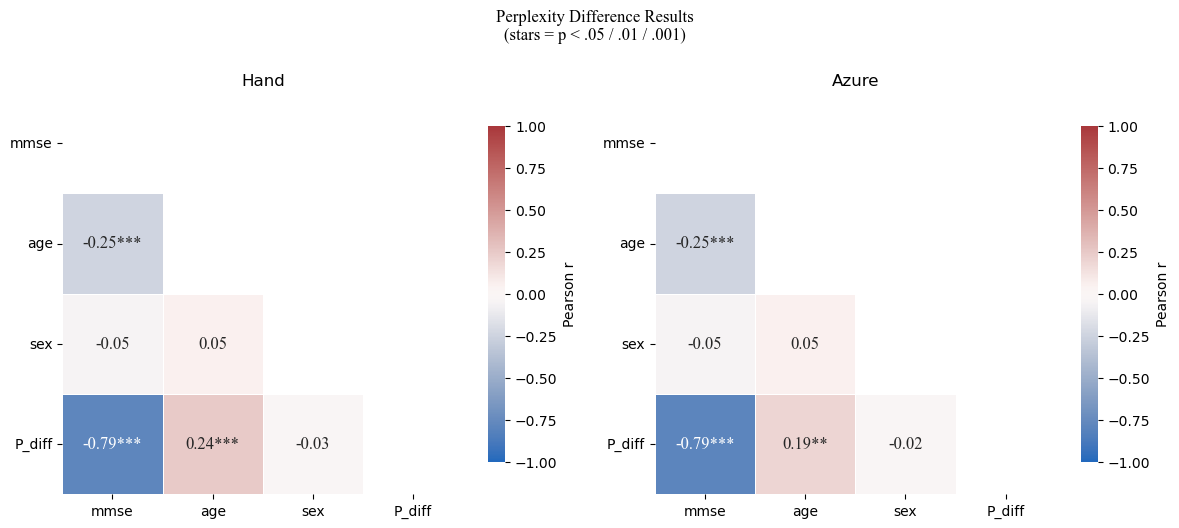

In [16]:
cols = ["mmse", "age", "sex", "P_diff"]
plot_correlations_by_dataset(
    ppl_results, cols=cols, title="Perplexity Difference Results", do_all=False, groups=plot_groups)

<br><br><br>


<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
  <span style="vertical-align: middle;">🧩</span> Pragmatic Impairment
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

### Set Parameters

In [17]:
# Set parameters to use
gc_params = dict(
    # Windowing config
    window_size           = 10,     # Token window size
    min_tokens_per_window =  5,     # Force minimum content per window
    
    # Coherence config
    frequency_weighting = "logfreq", # How to weigh tokens based on their frequencies: "logfreq" | "freq" | "none"
    aggregation_method  = "trimmed", # How to aggregate cosine scores: "mean" | "p10" | "trimmed"
    trim                = 0.10,      # Fraction to trim for "trimmed" mean
    entropy_alpha       = 0.5,       # Strength of entropy weighting
    normalize           = True,      # L2 normalize each token vector before averaging
)


### Calculate Pragmatic Impairment scores (Global Coherence)

In [18]:
# Collect score rows
gc_results = []

# ================================================================================
# Loop through the configs for each data source 
# ================================================================================
pbar = tqdm(range(len(DATA_SOURCES)), desc="Calculating Pragmatic Impairment scores", leave=True)
for config in DATA_SOURCES:
    
    # --------------------------------------------------------------------------------
    # Get data into the format to use
    # --------------------------------------------------------------------------------
    # Data to use
    gc_sentences = data_by_source[config.name]["sentences"]
    gc_meta      = config.meta.copy()
    
    # Get the format we need for coherence
    gc_data = {}
    for pID, sentences_list in gc_sentences.items():
        pID_df = pd.DataFrame({"response": sentences_list})
        pID_df.insert(0, "participant", "user")
        gc_data[pID] = pID_df
    
    # --------------------------------------------------------------------------------
    # Get scores for each participant
    # --------------------------------------------------------------------------------
    for pID, pID_df in tqdm(gc_data.items(), desc=f"[{config.name}] Calculating global coherence", leave=False):
        # Get the Pragmatic Impairment / global coherence score
        gc_score = pragmatic_global_coherence(pID_df, **gc_params)

        # Save the results
        gc_results.append({"srcID": config.name, "pID": pID, "global_coherence": gc_score})

    # Book-keeping
    pbar.update(1)
pbar.close()

# ================================================================================
# Create a DataFrame with the results of each participant for each source
# ================================================================================
gc_df = pd.DataFrame(gc_results); print(gc_df.shape)
gc_df = gc_df.rename(columns={"global_coherence": "gc"})

# Merge with meta data
gc_results = pd.merge(gc_meta, gc_df, on="pID", how="left")
gc_results.dropna(subset=["gc",], inplace=True)

#gc_results.head(2)

Calculating Pragmatic Impairment scores:   0%|          | 0/8 [00:00<?, ?it/s]

[Hand] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[Azure] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[Google_v1] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperLarge] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperMedium] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperSmall] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperBase] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

[WhisperTiny] Calculating global coherence:   0%|          | 0/222 [00:00<?, ?it/s]

(1776, 3)


### Inspect Results

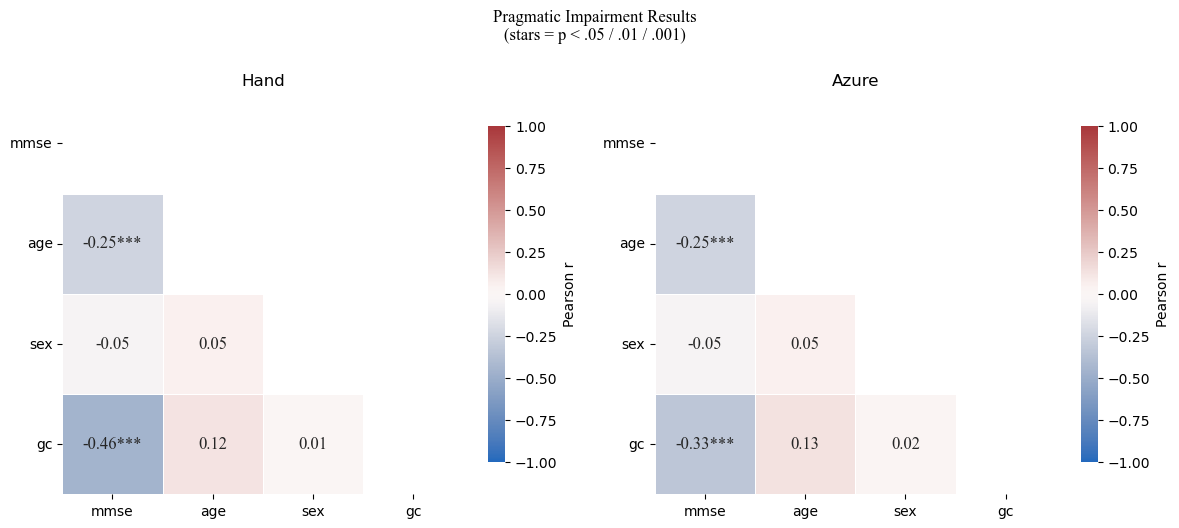

In [19]:
cols = ["mmse", "age", "sex", "gc"]
plot_correlations_by_dataset(
    gc_results, cols=cols, title="Pragmatic Impairment Results", do_all=False, groups=plot_groups)

<br><br><br>


<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
  <span style="vertical-align: middle;">📝</span> Altered Grammar
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">


### Calculate Altered Grammar scores 

In [20]:
# Collect score rows
ag_results = []

# ================================================================================
# Loop through the configs for each data source 
# ================================================================================
pbar = tqdm(range(len(DATA_SOURCES)), desc="Calculating Altered Grammar scores", leave=True)
for config in DATA_SOURCES:
    
    # --------------------------------------------------------------------------------
    # Get data into the format to use
    # --------------------------------------------------------------------------------
    # Data to use
    ag_features = data_by_source[config.name]["alt_gram"].copy()
    ag_meta     = config.meta.copy()
    
    # --------------------------------------------------------------------------------
    # Get scores for each participant
    # --------------------------------------------------------------------------------
    # Get the AlteredGrammar scores
    ag_res, ag_summaries = run_ml_ag(ag_features, source=config.name, verbose=0)
    ag_res["srcID"] = config.name
    ag_res = ag_res[["srcID", "pID", "reg", "cls"]]
    ag_results.append(ag_res)

    # Book-keeping
    pbar.update(1)
pbar.close()

# ================================================================================
# Create a DataFrame with the results of each participant for each source
# ================================================================================
ag_df = pd.concat(ag_results)

# Merge with meta data
ag_results = pd.merge(ag_meta, ag_df, on="pID", how="left")
ag_results.dropna(subset=["reg", "cls",], inplace=True)

#ag_results.head(2)

Calculating Altered Grammar scores:   0%|          | 0/8 [00:00<?, ?it/s]

### Inspect Results

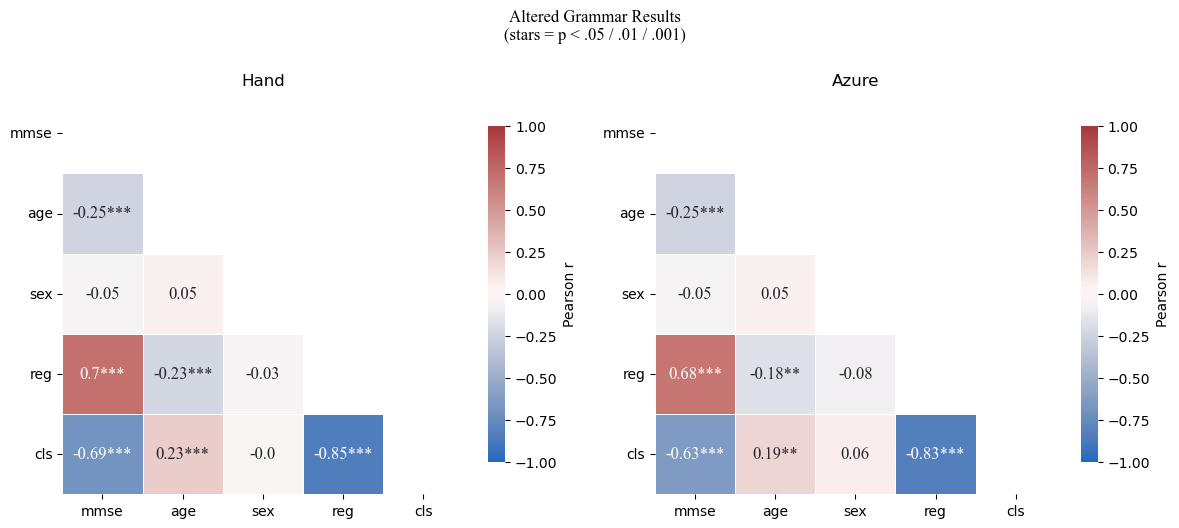

In [21]:
cols = ["mmse", "age", "sex", "reg", "cls"]
plot_correlations_by_dataset(
    ag_results, cols=cols, title="Altered Grammar Results", do_all=False, groups=plot_groups)

<br><br><br>


<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
    Combine Results 
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">


# Merge all 3 biomarkers + WER for all pIDs & all transcript sources

In [22]:
# Fresh copy of meta data
meta_combine = adr.copy()

# Which version of Altered Grammar to use (regressor or classifier probabilities)
ag_mode = "cls" # "cls" | "reg"

# Make copies
pp_combine = ppl_results.copy() #ppl_results[["srcID", "pID", "P_diff"    ]].copy()
gc_combine = gc_results[["srcID", "pID", "gc"        ]].copy()
ag_combine = ag_results[["srcID", "pID", "cls", "reg"]].copy() # "cls" | "reg"
wr_combine = wer_df    [["srcID", "pID", "WER"       ]].copy()

# Merge with meta data
combined_results = (
    pp_combine
    #.merge(pp_combine, on=["srcID", "pID"], how="left")
    .merge(gc_combine, on=["srcID", "pID"], how="left")
    .merge(ag_combine, on=["srcID", "pID"], how="left")
    .merge(wr_combine, on=["srcID", "pID"], how="left")
    .dropna(subset=["mmse", "P_diff", "gc", "cls", "reg"])
)

# Rename biomarker columns
combined_results = combined_results.rename(columns={
    #"P_diff": "Perplexity_Difference", "global_coherence": "Pragmatic_Impairment", #ag_mode: "Altered_Grammar"
})


# Drop some other columns
combined_results.drop(["MoCA", "ppl_ad", "ppl_cn"], axis=1, inplace=True)

# Working copy to modify in other areas
res_base = combined_results.copy()

# Display
print(combined_results.shape)
combined_results.head(5)

(1765, 13)


,pID,age,sex,edu,lang,dx,mmse,srcID,P_diff,gc,cls,reg,WER
0,adrso188,53,0,9.0,en,ProbableAD,23.0,Hand,-2.066512,0.763087,0.307425,18.962086,0.000000
1,adrso188,53,0,9.0,en,ProbableAD,23.0,Azure,1.409672,0.765043,0.182735,25.006819,0.285714
2,adrso188,53,0,9.0,en,ProbableAD,23.0,Google_v1,8.912236,0.791555,0.740052,21.167480,0.589286
3,adrso188,53,0,9.0,en,ProbableAD,23.0,WhisperLarge,-2.000635,0.739302,0.896280,17.479559,0.196429
4,adrso188,53,0,9.0,en,ProbableAD,23.0,WhisperMedium,-1.749289,0.755399,0.913844,17.953039,0.196429


# Rename biomarker columns to be more presentable

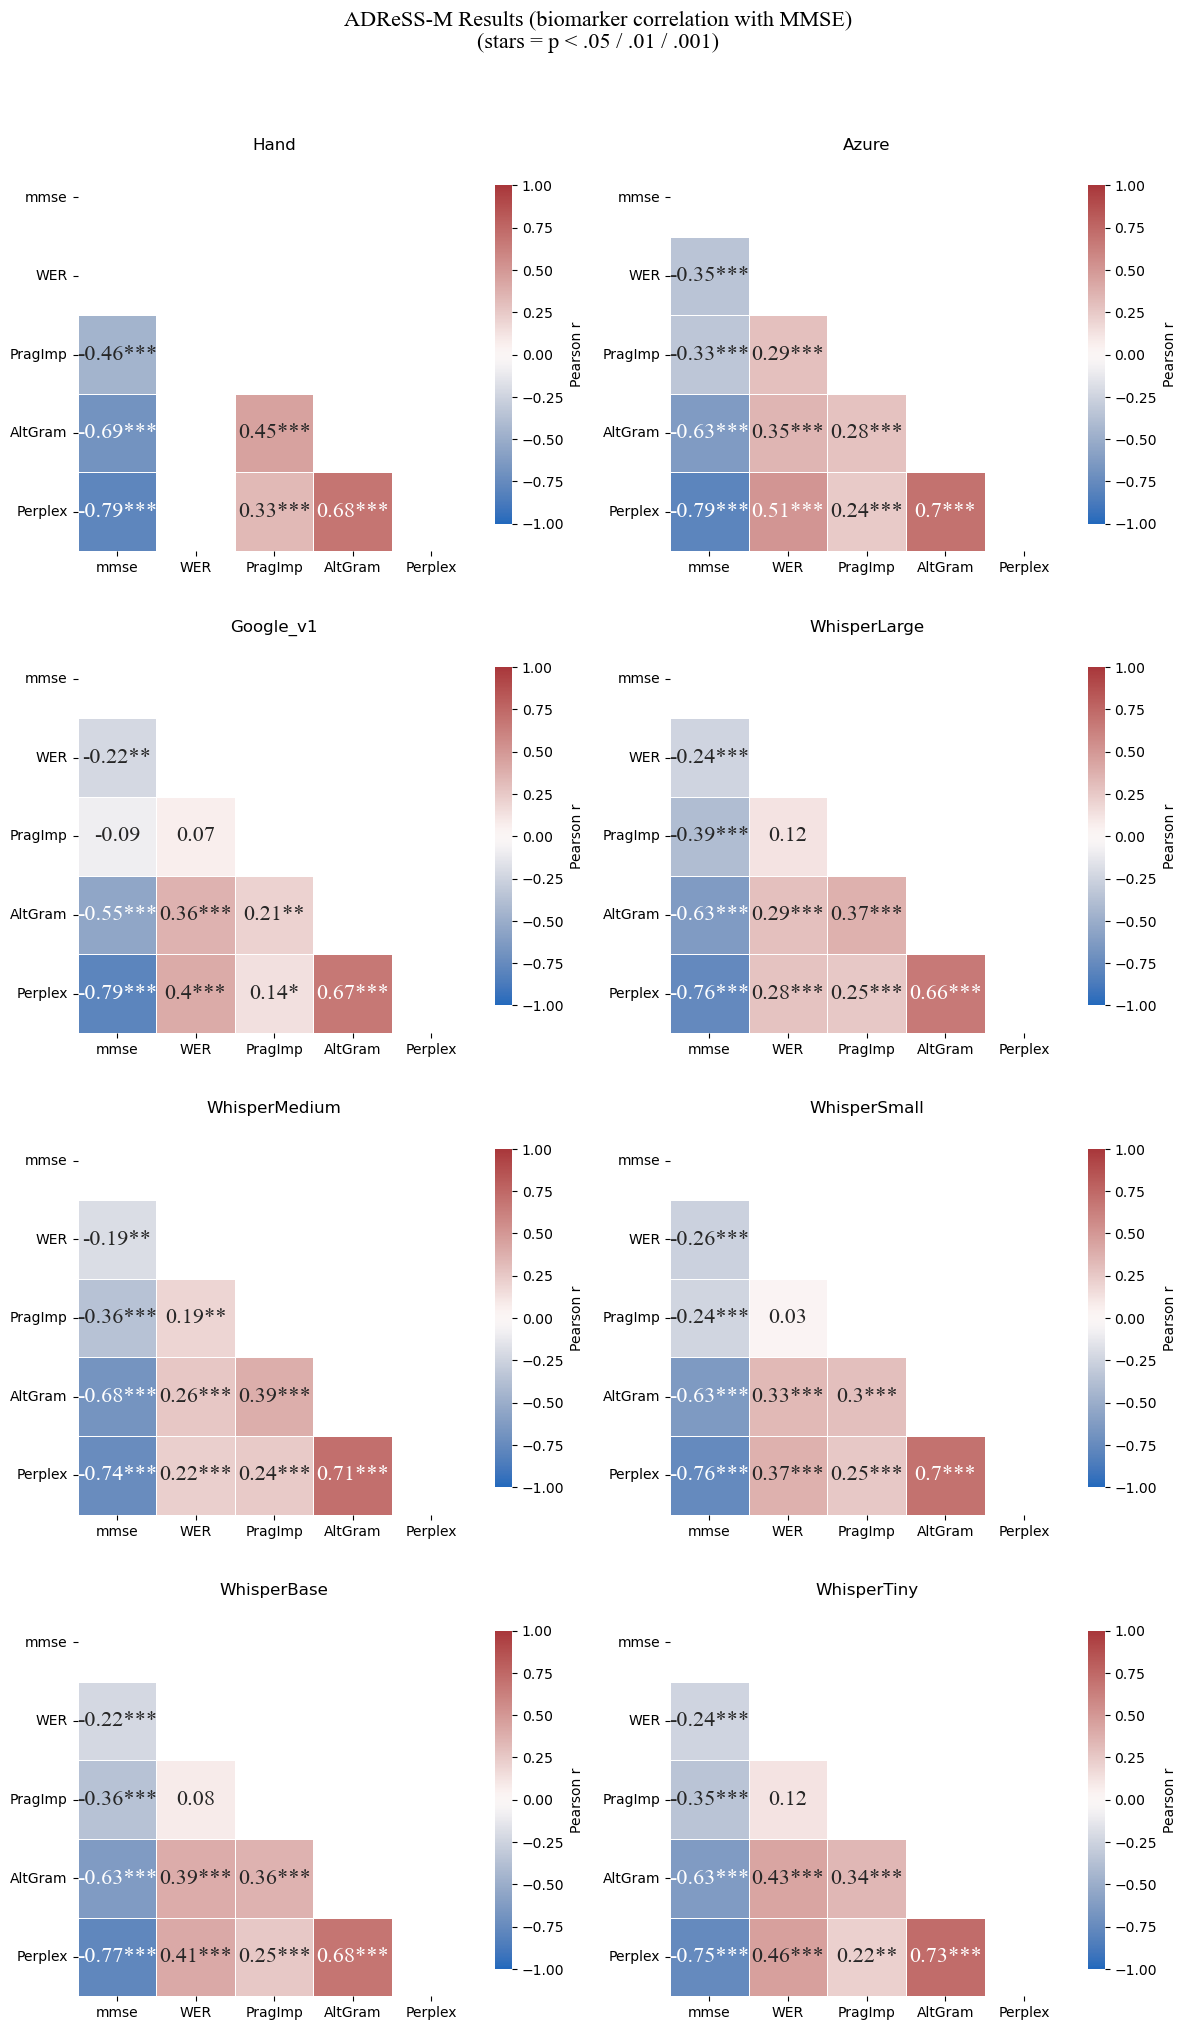

In [23]:
res_renamed = res_base.copy()
res_renamed = res_renamed.rename(columns={
    "gc": "PragImp", "P_diff": "Perplex", "cls": "AltGram", "reg": "Gram_r"
})

# Plot
cols = ["mmse", "WER", "PragImp", "AltGram", "Perplex"] #  "age", "sex", "WER",
plot_correlations_by_dataset(
    res_renamed, cols=cols, title="ADReSS-M Results (biomarker correlation with MMSE)",
    font_size = 16, 
    do_all    = False, 
    groups    = None, # None | plot_groups | (set this to none to see them all)
)


<br><br><br>


<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
    Meta-Analysis
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">


In [24]:
corr_table, fisher_corr_table, base_wer_corrs, fish_wer_corrs = build_meta_correlation_table(
    res_base = res_base,      # Combined results DataFrame (pre-rename)
    wer_df   = wer_df,        # WER DataFrame with 'srcID', 'pID', 'WER' columns
)

--------------------------------------------------------------------------------
 Pearson Correlation Table (biomarkers vs. MMSE)
--------------------------------------------------------------------------------


,WER,|,PragImp,PragImp_p,|,AltGram,AltGram_p,|,Perplex,Perplex_p,|,Gram_r,Gram_r_p
srcID,,,,,,,,,,,,,
Hand,0.0000,|,0.4585,0.0000,|,0.6911,0.0,|,0.7882,0.0,|,0.7033,0.0
WhisperMedium,0.2278,|,0.3647,0.0000,|,0.6834,0.0,|,0.7361,0.0,|,0.6242,0.0
WhisperLarge,0.2314,|,0.3941,0.0000,|,0.6297,0.0,|,0.7598,0.0,|,0.6203,0.0
WhisperSmall,0.2455,|,0.2362,0.0004,|,0.6332,0.0,|,0.7564,0.0,|,0.6412,0.0
Azure,0.3086,|,0.3297,0.0000,|,0.6299,0.0,|,0.7926,0.0,|,0.6825,0.0
WhisperBase,0.3107,|,0.3637,0.0000,|,0.6319,0.0,|,0.7746,0.0,|,0.6000,0.0
WhisperTiny,0.3465,|,0.3492,0.0000,|,0.6261,0.0,|,0.7549,0.0,|,0.5893,0.0
Google_v1,0.4419,|,0.0885,0.1917,|,0.5500,0.0,|,0.7910,0.0,|,0.5110,0.0


 Meta-Correlation Table (Pearson r & Fisher-z)


Pearson r             Fisher-z            
                       |  r_vs_WER p_vs_WER  | r_vs_WER p_vs_WER  |
metric                                                             
Altered Grammar        |   -0.8590   0.0133  |  -0.8496   0.0155  |
AltGram Regressor      |   -0.7341   0.0603  |  -0.7016   0.0789  |
Pragmatic Impairment   |   -0.6977   0.0813  |  -0.6933   0.0841  |
Perplexity Difference  |    0.6791   0.0934  |   0.6813   0.0919  |


<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

<h1 style="font-size: 48px; margin: 0; text-align: left;">
    Tables & Figures for the Paper
</h1>

<hr style="height: 6px; border: none; background: linear-gradient(90deg, #4b6cb7 0%, #AA3939 100%);">

## TODO: Add lines to each of these that save a version with a high DPI

---
### Meta-correlation Plots
Fisher-z transformed correlation coefficients between MMSE scores and biomarker values derived from each transcript source. 


 Pearson r Meta-Correlation


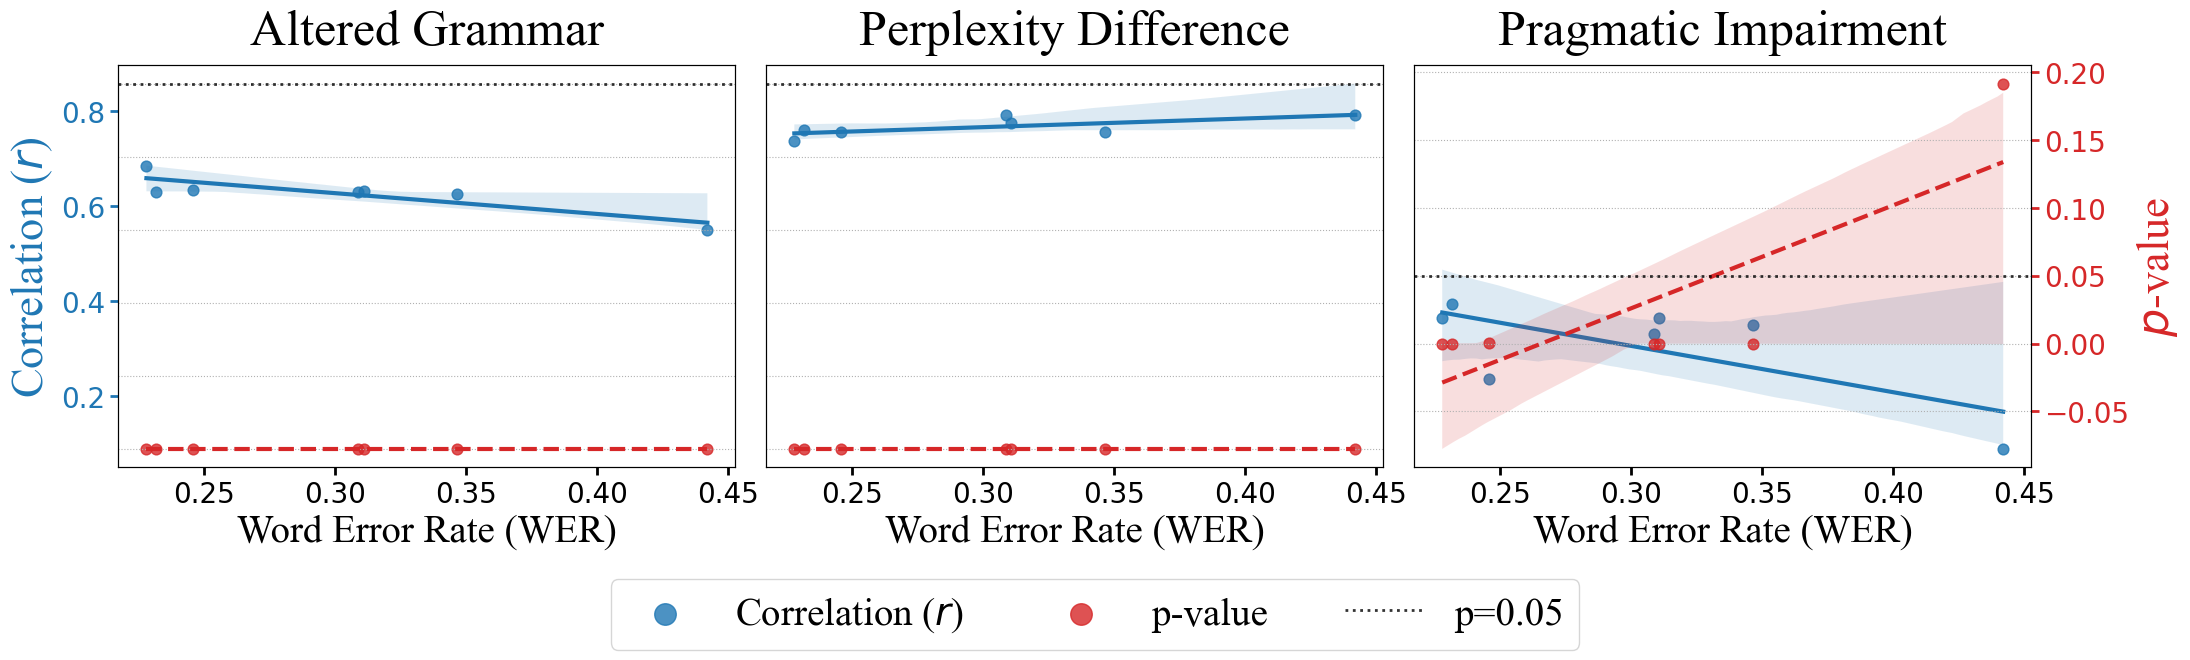

 Fisher-z Meta-Correlation


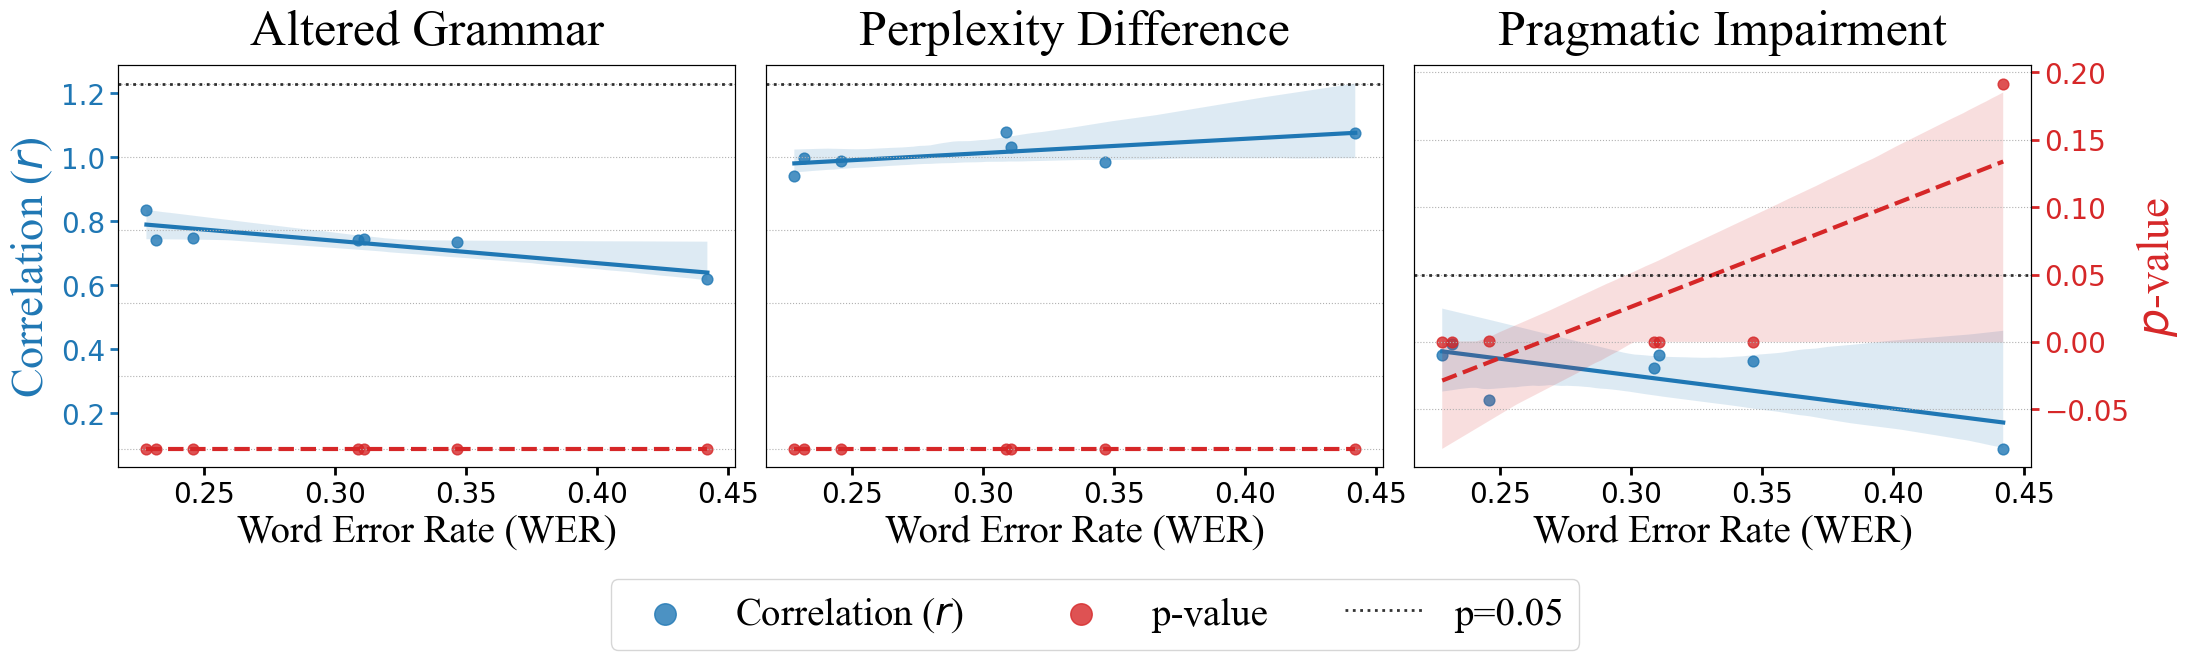

In [25]:
# Pearson r
print(f"{H_LINE_1a}{BOLD} Pearson r Meta-Correlation{RESET}{H_LINE_1b}")
plot_meta_correlations(
    corr_table, # corr_table fisher_corr_table
    ["AltGram", "Perplex", "PragImp"] , #BIOMARKER_COLS,
    BIOMARKER_NAMES,
)

# Fisher-z
print(f"{H_LINE_1a}{BOLD} Fisher-z Meta-Correlation{RESET}{H_LINE_1b}")
plot_meta_correlations(
    fisher_corr_table, # corr_table fisher_corr_table
    ["AltGram", "Perplex", "PragImp"] , #BIOMARKER_COLS,
    BIOMARKER_NAMES,
)

---
### Heatmap & Boxplots
"Figure 1: Biomarker Performance Across Transcript Conditions"


**TODO:** Maybe this should also take the `corr_table` as input


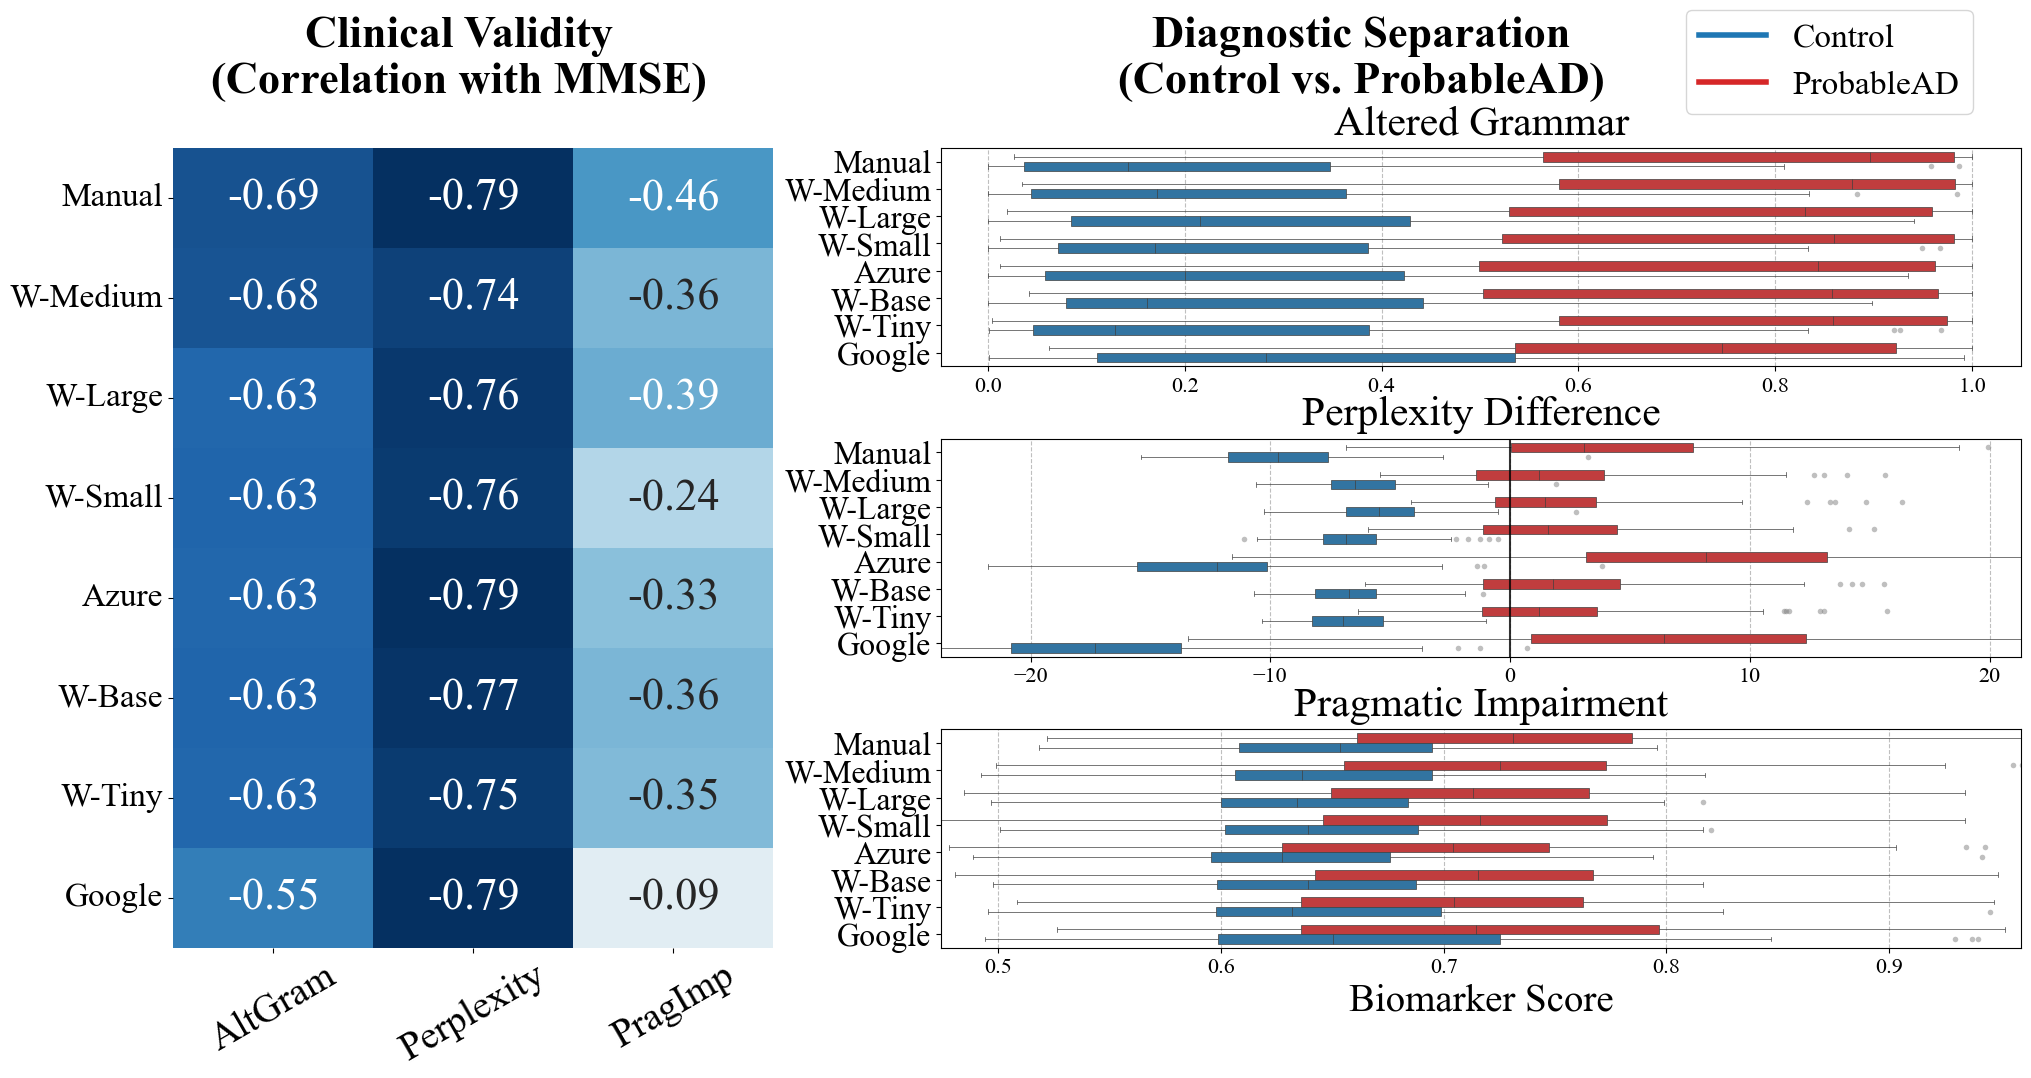

In [26]:
plot_heatmap_and_boxplots(
    res_base        = res_base,
    wer_df          = wer_df,          # WER DataFrame with 'srcID', 'pID', 'WER' columns
    src_map_short   = SRC_MAP_SHORT,
    biomarker_names = BIOMARKER_NAMES,
    rename_map      = RENAME_MAP,
)

---
### Biomarker Stability (adjusted formula for negatives)


Comparing 'Hand' against 7 ASR systems:
  ['Azure', 'Google_v1', 'WhisperLarge', 'WhisperMedium', 'WhisperSmall', 'WhisperBase', 'WhisperTiny']


,Stability (sj)
Biomarker,
PragImp,0.062622
Gram_r,0.145114
AltGram,0.522719
Perplex,0.724587


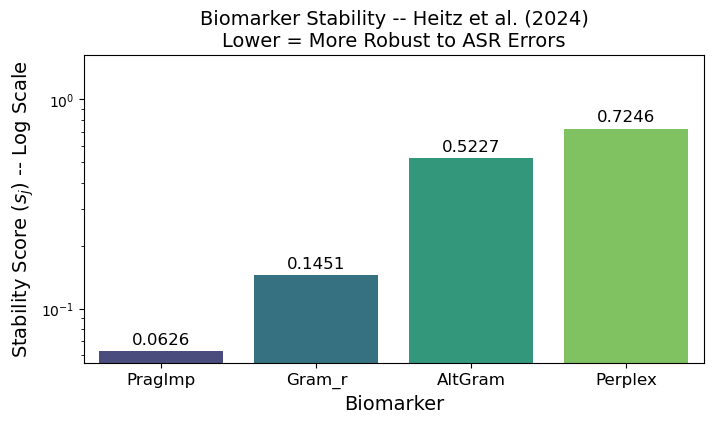

In [27]:
# Calculations 
stability_df = calculate_feature_stability(
    df         = res_renamed,
    biomarkers = BIOMARKER_COLS,
    manual_id  = "Hand",         # Reference transcript source
)
display(stability_df)

# Plot
plot_feature_stability(
    stability_df   = stability_df,
    title_size     = 14, 
    axis_size      = 14, 
    bar_label_size = 12,
)

---
### Agreement Metrics

Comparing 'Hand' against 7 ASR systems:
  ['Azure', 'Google_v1', 'WhisperLarge', 'WhisperMedium', 'WhisperSmall', 'WhisperBase', 'WhisperTiny']



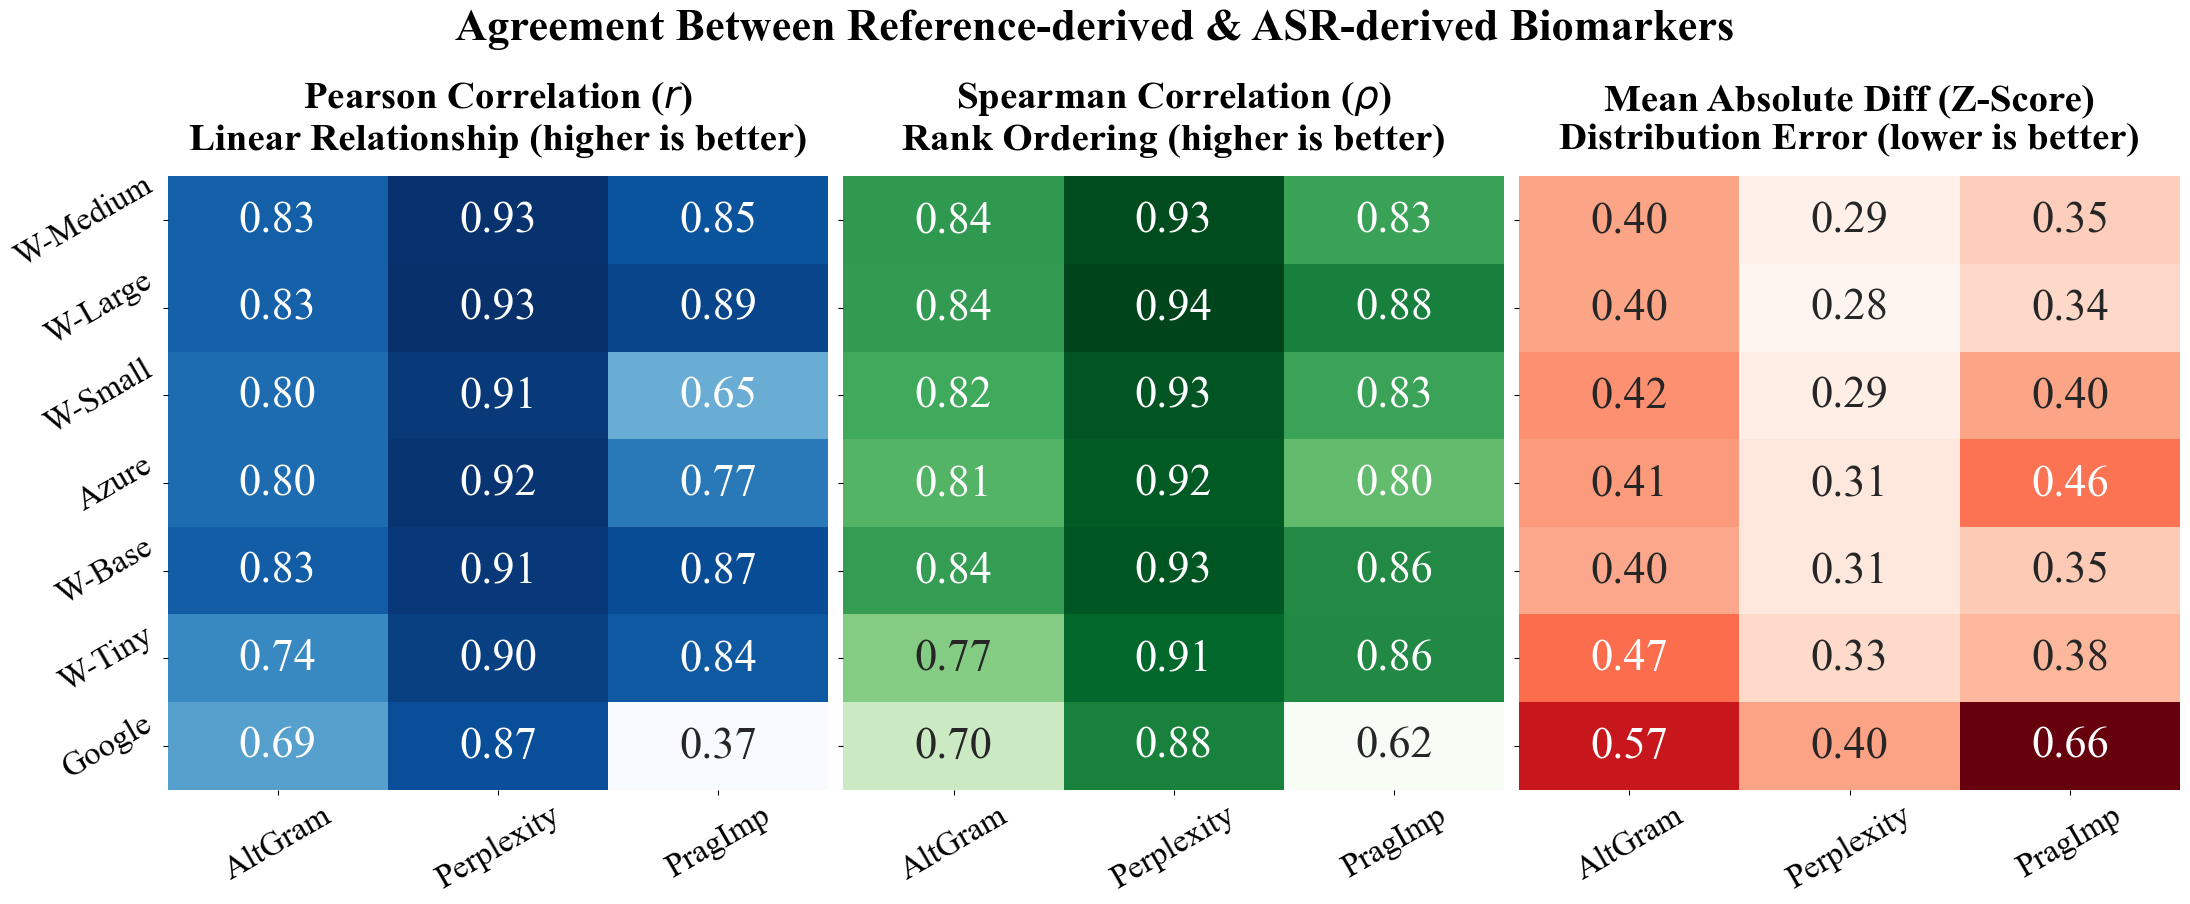

In [28]:
# Calculations 
agreement_df = calculate_agreement_metrics(
    df         = res_renamed,
    biomarkers = BIOMARKER_COLS, # Biomarkers to do this for
    manual_id  = "Hand",         # Reference transcript source
); print()

# Plot
plot_agreement_heatmaps(
    agreement_df  = agreement_df,
    wer_df        = wer_df,
    src_map       = SRC_MAP_SHORT,
    biomarker_map = None,   # Short display name map for biomarkers
)

---
### WER `LaTeX` table
**TODO:** Make a version that prints normally (like `display(df)`) + make these little headers more informative/useful


In [29]:
generate_wer_latex_table(
    res_base       = res_base,
    wer_df         = wer_df,
    target_sources = None,   # List of srcID values to include (in order)
)


LATEX TABLE ROWS (Copy/Paste)
Hand                 &    0.0 $\pm$ 0.0 &    0.0 $\pm$ 0.0 &         0.0 &         nan \\
Azure                &  21.8 $\pm$ 14.4 &  38.3 $\pm$ 23.5 &  16.5^{***} & -0.35^{***} \\
Google_v1            &  37.1 $\pm$ 21.4 &  49.3 $\pm$ 20.4 &  12.2^{***} &  -0.22^{**} \\
WhisperLarge         &  16.3 $\pm$ 10.6 &  28.7 $\pm$ 21.8 &  12.4^{***} & -0.24^{***} \\
WhisperMedium        &  17.4 $\pm$ 12.1 &  27.2 $\pm$ 17.5 &   9.8^{***} &  -0.19^{**} \\
WhisperSmall         &  17.8 $\pm$ 12.1 &  30.1 $\pm$ 18.7 &  12.3^{***} & -0.26^{***} \\
WhisperBase          &  23.9 $\pm$ 15.1 &  36.6 $\pm$ 21.9 &  12.7^{***} & -0.22^{***} \\
WhisperTiny          &  27.5 $\pm$ 17.8 &  40.6 $\pm$ 20.9 &  13.2^{***} & -0.24^{***} \\
Note: * p<0.05, ** p<0.01, *** p<0.001
WER values multiplied by 100 to show as percentages


<br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br><br>